In [1]:
# # === 1) БАЗОВІ ПАКЕТИ ТА PYTORCH (CUDA 12.1) ===
# %pip install --upgrade pip wheel setuptools

# # PyTorch з підтримкою CUDA (під твій драйвер CUDA 12.9 сумісно з cu129)
# %pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129

# # Корисні бібліотеки для ноутбука і нашого пайплайна
# %pip install numpy pillow matplotlib opencv-python "albumentations>=2.0.0,<3.0" tqdm ipywidgets kaggle

# # Спроба поставити готове колесо pycocotools
# %pip install pycocotools
# %pip install pandas matplotlib numpy seaborn jupyterlab notebook ipywidgets

# # === 2) FALLBACK: якщо pycocotools не імпортується, збираємо з джерел ===
# import importlib, sys, subprocess
# try:
#     importlib.import_module("pycocotools")
# except Exception as e:
#     print("pycocotools wheel недоступний для цієї версії Python. Ставимо з джерел…")
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "cython"])
#     subprocess.check_call([
#         sys.executable, "-m", "pip", "install",
#         "git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI"
#     ])
# try:
#     import sys, subprocess
#     subprocess.run(
#         [sys.executable, "-m", "jupyter", "nbextension", "enable", "--py", "widgetsnbextension", "--sys-prefix"],
#         check=False
#     )
# except Exception:
#     pass




In [2]:
# === 3) ШВИДКА ПЕРЕВІРКА СЕРЕДОВИЩА ===
import torch, albumentations as A, numpy as np, cv2, PIL, matplotlib
print("torch:", torch.__version__, "| CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("torchvision:", __import__("torchvision").__version__)
print("albumentations:", A.__version__)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("matplotlib:", matplotlib.__version__)

torch: 2.9.0+cu130 | CUDA available?: True
GPU: NVIDIA GeForce RTX 3060
torchvision: 0.24.0+cu130
albumentations: 2.0.8
numpy: 2.3.3
opencv: 4.11.0
Pillow: 11.3.0
matplotlib: 3.10.6
torchvision: 0.24.0+cu130
albumentations: 2.0.8
numpy: 2.3.3
opencv: 4.11.0
Pillow: 11.3.0
matplotlib: 3.10.6


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # швидші kernels для стабільного розміру
print("Train on:", device)

Train on: cuda


In [4]:
# Cell 1. Imports, seed, device

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)
import torchvision.transforms.functional as TF

from PIL import Image
from pycocotools.coco import COCO

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
# Cell 2. Dataset config (шляхи, image ids, mapping category→label)
DATA_ROOT = '../coco2017'
IMAGES_DIR = os.path.join(DATA_ROOT, "train2017")
ANN_FILE = os.path.join(DATA_ROOT, "annotations", "instances_train2017.json")

base_coco = COCO(ANN_FILE)
all_img_ids = base_coco.getImgIds()
print("Total images in annotations:", len(all_img_ids))

# Обмежуємо кількість для швидкого експерименту
MAX_IMAGES = 1000  # або None, якщо хочеш повний датасет
if MAX_IMAGES is not None:
    all_img_ids = all_img_ids[:MAX_IMAGES]
print("Using images:", len(all_img_ids))

cat_ids = base_coco.getCatIds()
cat_id_to_label = {cat_id: i + 1 for i, cat_id in enumerate(cat_ids)}  # 0 = background
print("Num classes (with background):", len(cat_ids) + 1)

# Train/val split
random.shuffle(all_img_ids)
split = int(0.9 * len(all_img_ids))
train_img_ids = all_img_ids[:split]
val_img_ids = all_img_ids[split:]

print("Train images:", len(train_img_ids), " Val images:", len(val_img_ids))


loading annotations into memory...
Done (t=9.68s)
creating index...
Done (t=9.68s)
creating index...
index created!
Total images in annotations: 118287
Using images: 1000
Num classes (with background): 81
Train images: 900  Val images: 100
index created!
Total images in annotations: 118287
Using images: 1000
Num classes (with background): 81
Train images: 900  Val images: 100


In [6]:
# Cell 3. Semantic segmentation dataset на основі COCO

class CocoSemanticSegmentationDataset(Dataset):
    """
    Semantic segmentation on a COCO-style dataset.

    Returns:
      - image: PIL.Image (якщо transform=None) або torch.Tensor[3,H,W]
      - mask:  np.ndarray[H,W] або torch.Tensor[H,W] з мітками 0..num_classes-1
    """

    def __init__(
        self,
        images_dir: str,
        ann_file: str,
        img_ids,
        cat_id_to_label,
        transform=None,
    ):
        self.images_dir = images_dir
        self.coco = COCO(ann_file)
        self.img_ids = img_ids
        self.cat_id_to_label = cat_id_to_label
        self.num_classes = len(cat_id_to_label) + 1  # + background
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_dir, img_info["file_name"])
        img = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        h, w = img_info["height"], img_info["width"]
        mask = np.zeros((h, w), dtype=np.uint8)

        # Більші об'єкти перекривають менших
        anns_sorted = sorted(anns, key=lambda a: a.get("area", 0.0))
        for ann in anns_sorted:
            cat_id = ann["category_id"]
            label = self.cat_id_to_label.get(cat_id, 0)
            if label == 0:
                continue
            m = self.coco.annToMask(ann)  # 0/1
            mask[m == 1] = label

        if self.transform is not None:
            img, mask = self.transform(img, mask)

        return img, mask


In [7]:
# Cell 4. Трансформації для train / val

class SegTrainTransform:
    def __init__(self, size: int = 256):
        self.size = size
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, img: Image.Image, mask: np.ndarray):
        # Resize
        img = img.resize((self.size, self.size), Image.BILINEAR)
        mask = Image.fromarray(mask).resize((self.size, self.size), Image.NEAREST)
        # Random horizontal flip
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        # To tensor + normalize
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=self.mean, std=self.std)
        mask_t = torch.from_numpy(np.array(mask, dtype=np.int64))
        return img_t, mask_t


class SegValTransform:
    def __init__(self, size: int = 256):
        self.size = size
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, img: Image.Image, mask: np.ndarray):
        img = img.resize((self.size, self.size), Image.BILINEAR)
        mask = Image.fromarray(mask).resize((self.size, self.size), Image.NEAREST)
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=self.mean, std=self.std)
        mask_t = torch.from_numpy(np.array(mask, dtype=np.int64))
        return img_t, mask_t


In [8]:
# Cell 5. Datasets + DataLoaders

train_transform = SegTrainTransform(size=256)
val_transform = SegValTransform(size=256)

train_dataset = CocoSemanticSegmentationDataset(
    IMAGES_DIR,
    ANN_FILE,
    img_ids=train_img_ids,
    cat_id_to_label=cat_id_to_label,
    transform=train_transform,
)
val_dataset = CocoSemanticSegmentationDataset(
    IMAGES_DIR,
    ANN_FILE,
    img_ids=val_img_ids,
    cat_id_to_label=cat_id_to_label,
    transform=val_transform,
)

num_classes = train_dataset.num_classes
print("Num classes (with background):", num_classes)

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)


loading annotations into memory...
Done (t=7.95s)
creating index...
Done (t=7.95s)
creating index...
index created!
loading annotations into memory...
index created!
loading annotations into memory...
Done (t=8.03s)
creating index...
Done (t=8.03s)
creating index...
index created!
Num classes (with background): 81
index created!
Num classes (with background): 81


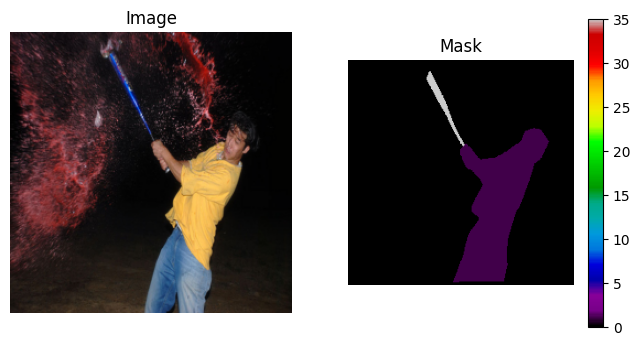

In [9]:
# Cell 6. Візуалізація одного прикладу

def show_sample(dataset, idx: int = 0):
    img, mask = dataset[idx]
    if isinstance(img, torch.Tensor):
        img_np = img.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)
    else:
        img_np = np.array(img) / 255.0

    mask_np = mask.cpu().numpy() if isinstance(mask, torch.Tensor) else mask

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    im = axes[1].imshow(mask_np, cmap="nipy_spectral")
    axes[1].set_title("Mask")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1])
    plt.show()


show_sample(train_dataset, idx=0)


In [18]:
# Cell 7. Метрики: pixel accuracy, mIoU

def _fast_hist(label_true, label_pred, n_class):
    mask = (label_true >= 0) & (label_true < n_class)
    hist = np.bincount(
        n_class * label_true[mask].astype(int) + label_pred[mask].astype(int),
        minlength=n_class ** 2,
    ).reshape(n_class, n_class)
    return hist


def compute_scores(hist):
    acc = np.diag(hist).sum() / hist.sum()
    acc_cls = np.diag(hist) / hist.sum(axis=1)
    acc_cls = np.nanmean(acc_cls)
    iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))
    mean_iu = np.nanmean(iu)
    freq = hist.sum(axis=1) / hist.sum()
    fwavacc = (freq[freq > 0] * iu[freq > 0]).sum()
    return {
        "pixel_acc": float(acc),
        "mean_acc": float(acc_cls),
        "mean_iou": float(mean_iu),
        "fwavacc": float(fwavacc),
    }


@torch.no_grad()
def evaluate_segmentation_model(model, data_loader, device, num_classes: int):
    model.eval()
    hist = np.zeros((num_classes, num_classes), dtype=np.float64)

    for images, masks in data_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        # DeepLab case
        if isinstance(outputs, dict) and "out" in outputs:
            logits = outputs["out"]

        # HuggingFace SegFormer case
        elif hasattr(outputs, "logits"):
            logits = outputs.logits

        else:
            raise ValueError("Unknown model output format:", outputs)


        logits = F.interpolate(
            logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
        )
        preds = torch.argmax(logits, dim=1)

        for lt, lp in zip(masks, preds):
            lt_np = lt.cpu().numpy().astype(np.int64)
            lp_np = lp.cpu().numpy().astype(np.int64)
            hist += _fast_hist(lt_np.flatten(), lp_np.flatten(), num_classes)

    return compute_scores(hist)

In [11]:
# Cell 8. DeepLabv3-ResNet50 (pretrained → fine-tune)

def build_deeplabv3_resnet50(num_classes: int, freeze_backbone: bool = True):
    weights = DeepLabV3_ResNet50_Weights.DEFAULT
    model = deeplabv3_resnet50(weights=weights)
    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False
    in_ch = model.classifier[-1].in_channels
    model.classifier[-1] = nn.Conv2d(in_ch, num_classes, kernel_size=1)
    return model


deeplab_model = build_deeplabv3_resnet50(num_classes, freeze_backbone=True).to(device)
criterion_dl = nn.CrossEntropyLoss(ignore_index=255)

optimizer_dl = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, deeplab_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

NUM_EPOCHS_DL = 5  # можеш змінити


In [12]:
# Cell 9. Одна епоха тренування DeepLab

def train_deeplab_one_epoch(model, loader, optimizer, device, criterion):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


In [13]:
# Cell 10. Тренування DeepLab на кілька епох

best_dl_state = None
best_dl_miou = 0.0
history_dl = []

for epoch in range(1, NUM_EPOCHS_DL + 1):
    train_loss = train_deeplab_one_epoch(
        deeplab_model, train_loader, optimizer_dl, device, criterion_dl
    )
    metrics_val = evaluate_segmentation_model(
        deeplab_model, val_loader, device, num_classes
    )
    history_dl.append({"epoch": epoch, "train_loss": train_loss, **metrics_val})
    print(
        f"[DeepLab] Epoch {epoch}: "
        f"loss={train_loss:.4f}, "
        f"mIoU={metrics_val['mean_iou']:.4f}, "
        f"pixAcc={metrics_val['pixel_acc']:.4f}"
    )
    if metrics_val["mean_iou"] > best_dl_miou:
        best_dl_miou = metrics_val["mean_iou"]
        best_dl_state = deeplab_model.state_dict()

print("Best DeepLab mIoU:", best_dl_miou)
if best_dl_state is not None:
    deeplab_model.load_state_dict(best_dl_state)


C:\Users\adm\AppData\Local\Temp\ipykernel_31152\1934538644.py:14: RuntimeWarning: invalid value encountered in divide
  acc_cls = np.diag(hist) / hist.sum(axis=1)
C:\Users\adm\AppData\Local\Temp\ipykernel_31152\1934538644.py:16: RuntimeWarning: invalid value encountered in divide
  iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))


[DeepLab] Epoch 1: loss=2.6404, mIoU=0.0301, pixAcc=0.6991
[DeepLab] Epoch 2: loss=1.4605, mIoU=0.0546, pixAcc=0.7684
[DeepLab] Epoch 2: loss=1.4605, mIoU=0.0546, pixAcc=0.7684
[DeepLab] Epoch 3: loss=1.0759, mIoU=0.0600, pixAcc=0.7812
[DeepLab] Epoch 3: loss=1.0759, mIoU=0.0600, pixAcc=0.7812
[DeepLab] Epoch 4: loss=0.9500, mIoU=0.0803, pixAcc=0.7821
[DeepLab] Epoch 4: loss=0.9500, mIoU=0.0803, pixAcc=0.7821
[DeepLab] Epoch 5: loss=0.8805, mIoU=0.1023, pixAcc=0.7960
Best DeepLab mIoU: 0.10226068503136065
[DeepLab] Epoch 5: loss=0.8805, mIoU=0.1023, pixAcc=0.7960
Best DeepLab mIoU: 0.10226068503136065


In [14]:
# Cell 11. Raw датасети + SegformerImageProcessor

raw_train_dataset = CocoSemanticSegmentationDataset(
    IMAGES_DIR,
    ANN_FILE,
    img_ids=train_img_ids,
    cat_id_to_label=cat_id_to_label,
    transform=None,
)
raw_val_dataset = CocoSemanticSegmentationDataset(
    IMAGES_DIR,
    ANN_FILE,
    img_ids=val_img_ids,
    cat_id_to_label=cat_id_to_label,
    transform=None,
)

processor = SegformerImageProcessor(
    do_resize=True,
    size={"height": 256, "width": 256},
    do_normalize=True,
    do_rescale=True,
)


loading annotations into memory...
Done (t=8.78s)
creating index...
Done (t=8.78s)
creating index...
index created!
loading annotations into memory...
index created!
loading annotations into memory...
Done (t=8.82s)
creating index...
Done (t=8.82s)
creating index...
index created!
index created!


In [15]:
# Cell 12. Wrapper-датасети для SegFormer

class CocoSegformerWrapper(Dataset):
    def __init__(self, base_dataset: Dataset, processor: SegformerImageProcessor):
        self.base = base_dataset
        self.processor = processor

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx: int):
        img, mask = self.base[idx]  # img: PIL.Image, mask: np.ndarray або tensor
        if isinstance(mask, torch.Tensor):
            mask_np = mask.cpu().numpy()
        else:
            mask_np = mask

        encoded = self.processor(
            images=np.array(img), segmentation_maps=mask_np, return_tensors="pt"
        )
        pixel_values = encoded["pixel_values"].squeeze(0)  # [3,H,W]
        labels = encoded["labels"].squeeze(0).long()       # [H,W]
        return pixel_values, labels


segformer_train_dataset = CocoSegformerWrapper(raw_train_dataset, processor)
segformer_val_dataset = CocoSegformerWrapper(raw_val_dataset, processor)

segformer_train_loader = DataLoader(
    segformer_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
segformer_val_loader = DataLoader(
    segformer_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


In [16]:
# Cell 13. SegFormer-B0 (pretrained → fine-tune)

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
)
segformer_model.to(device)

optimizer_sf = torch.optim.AdamW(
    segformer_model.parameters(), lr=6e-5, weight_decay=1e-4
)

NUM_EPOCHS_SF = 5  # можна змінити


def train_segformer_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    for pixel_values, labels in loader:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * pixel_values.size(0)

    return running_loss / len(loader.dataset)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([81]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([81, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# Cell 14. Тренування SegFormer-B0

best_sf_state = None
best_sf_miou = 0.0
history_sf = []

for epoch in range(1, NUM_EPOCHS_SF + 1):
    train_loss = train_segformer_one_epoch(
        segformer_model, segformer_train_loader, optimizer_sf, device
    )
    metrics_val = evaluate_segmentation_model(
        segformer_model, segformer_val_loader, device, num_classes
    )
    history_sf.append({"epoch": epoch, "train_loss": train_loss, **metrics_val})
    print(
        f"[SegFormer] Epoch {epoch}: "
        f"loss={train_loss:.4f}, "
        f"mIoU={metrics_val['mean_iou']:.4f}, "
        f"pixAcc={metrics_val['pixel_acc']:.4f}"
    )
    if metrics_val["mean_iou"] > best_sf_miou:
        best_sf_miou = metrics_val["mean_iou"]
        best_sf_state = segformer_model.state_dict()

print("Best SegFormer mIoU:", best_sf_miou)
if best_sf_state is not None:
    segformer_model.load_state_dict(best_sf_state)


C:\Users\adm\AppData\Local\Temp\ipykernel_31152\4009555430.py:14: RuntimeWarning: invalid value encountered in divide
  acc_cls = np.diag(hist) / hist.sum(axis=1)
C:\Users\adm\AppData\Local\Temp\ipykernel_31152\4009555430.py:16: RuntimeWarning: invalid value encountered in divide
  iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))


[SegFormer] Epoch 1: loss=1.8383, mIoU=0.0151, pixAcc=0.7213
[SegFormer] Epoch 2: loss=1.3213, mIoU=0.0175, pixAcc=0.7466
[SegFormer] Epoch 2: loss=1.3213, mIoU=0.0175, pixAcc=0.7466
[SegFormer] Epoch 3: loss=1.1190, mIoU=0.0185, pixAcc=0.7468
[SegFormer] Epoch 3: loss=1.1190, mIoU=0.0185, pixAcc=0.7468
[SegFormer] Epoch 4: loss=1.0239, mIoU=0.0180, pixAcc=0.7483
[SegFormer] Epoch 4: loss=1.0239, mIoU=0.0180, pixAcc=0.7483
[SegFormer] Epoch 5: loss=0.9559, mIoU=0.0201, pixAcc=0.7486
Best SegFormer mIoU: 0.02007816662968276
[SegFormer] Epoch 5: loss=0.9559, mIoU=0.0201, pixAcc=0.7486
Best SegFormer mIoU: 0.02007816662968276


In [45]:
# Cell 15. Grad-CAM + SmoothGrad + overlay-функції

class SegmentationGradCAM:
    def __init__(self, model, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_hook = target_layer.register_forward_hook(self._forward_hook)
        # Use full backward hook for compatibility with recent PyTorch
        self.bwd_hook = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image: torch.Tensor, target_class: int, device):
        """
        image: [1,3,H,W] (normalized)
        target_class: int
        """
        self.model.eval()
        self.model.zero_grad()
        image = image.to(device)

        outputs = self.model(image)
        # Robustly handle DeepLab (dict with 'out') and SegFormer (object with .logits)
        if isinstance(outputs, dict) and "out" in outputs:
            logits = outputs["out"]
        elif hasattr(outputs, "logits"):
            logits = outputs.logits
        else:
            raise ValueError(f"Unknown model output format: {type(outputs)}")

        score = logits[:, target_class].mean()
        score.backward()

        A = self.activations  # [B,C,Hf,Wf]
        dY = self.gradients   # [B,C,Hf,Wf]

        weights = dY.mean(dim=(2, 3), keepdim=True)
        cam = (weights * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam, size=image.shape[-2:], mode="bilinear", align_corners=False
        )
        cam = cam.squeeze(0).squeeze(0)
        cam_np = cam.detach().cpu().numpy()
        cam_np = cam_np - cam_np.min()
        if cam_np.max() > 0:
            cam_np = cam_np / cam_np.max()
        return cam_np


In [ ]:
def smoothgrad_segmentation(
    model,
    image: torch.Tensor,
    target_class: int,
    device,
    n_samples: int = 25,
    noise_std_fraction: float = 0.1,
):
    """
    SmoothGrad: усереднюємо градієнти по зашумлених варіантах входу.
    image: [1,3,H,W] normalized
    """
    model.eval()
    img = image.to(device)
    img_min, img_max = img.min(), img.max()
    std = noise_std_fraction * (img_max - img_min)

    accumulated_grad = torch.zeros_like(img)

    for _ in range(n_samples):
        noisy_img = img + torch.randn_like(img) * std
        noisy_img.requires_grad_(True)

        outputs = model(noisy_img)
        # Robustly handle DeepLab (dict with 'out') and SegFormer (object with .logits)
        if isinstance(outputs, dict) and "out" in outputs:
            logits = outputs["out"]
        elif hasattr(outputs, "logits"):
            logits = outputs.logits
        else:
            raise ValueError(f"Unknown model output format: {type(outputs)}")

        score = logits[:, target_class].mean()
        grad, = torch.autograd.grad(score, noisy_img)
        accumulated_grad += grad.detach()

    avg_grad = accumulated_grad / n_samples
    saliency = avg_grad.abs().sum(dim=1, keepdim=False)  # [1,H,W]
    saliency = saliency.squeeze(0).detach().cpu().numpy()
    saliency = saliency - saliency.min()
    if saliency.max() > 0:
        saliency = saliency / saliency.max()
    return saliency


def overlay_heatmap_on_image(image_tensor: torch.Tensor, heatmap: np.ndarray, alpha=0.5):
    """
    image_tensor: [3,H,W], normalized (ImageNet stats)
    heatmap: [H,W], 0..1
    """
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    cmap = plt.get_cmap("jet")
    heatmap_color = cmap(heatmap)[..., :3]
    overlay = (1 - alpha) * img + alpha * heatmap_color
    overlay = np.clip(overlay, 0, 1)
    return img, overlay


def overlay_heatmap_on_segformer_input(
    pixel_values: torch.Tensor,
    heatmap: np.ndarray,
    image_mean,
    image_std,
    alpha=0.5,
):
    """
    pixel_values: [3,H,W] (normalized по processor.image_mean/std)
    heatmap: [H,W], 0..1
    """
    img = pixel_values.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array(image_mean)
    std = np.array(image_std)
    img = img * std + mean
    img = np.clip(img, 0, 1)

    cmap = plt.get_cmap("jet")
    heatmap_color = cmap(heatmap)[..., :3]
    overlay = (1 - alpha) * img + alpha * heatmap_color
    overlay = np.clip(overlay, 0, 1)
    return img, overlay


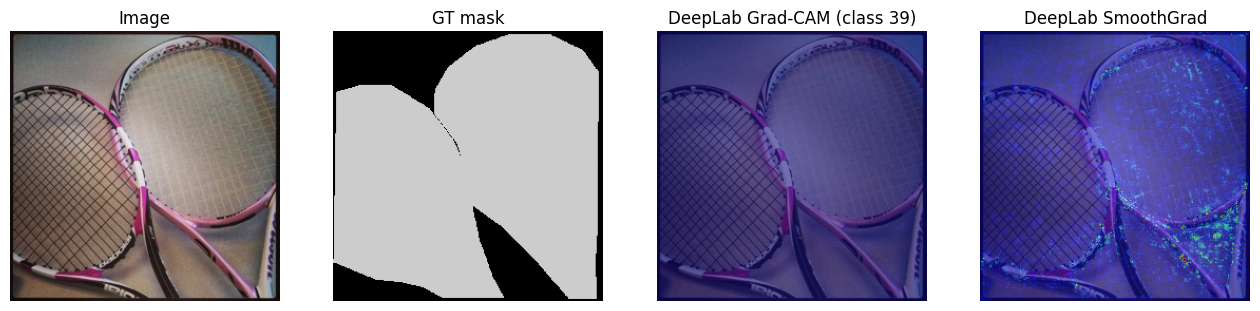

In [47]:
# Cell 16. Grad-CAM + SmoothGrad для DeepLabv3-ResNet50

deeplab_target_layer = deeplab_model.classifier[-1]
gradcam_dl = SegmentationGradCAM(deeplab_model, deeplab_target_layer)


deeplab_model.eval()
images_batch, masks_batch = next(iter(val_loader))
img = images_batch[0:1]  # [1,3,H,W]
mask = masks_batch[0]

mask_np = mask.cpu().numpy()
unique = np.unique(mask_np)
unique = unique[unique != 0]
target_class_dl = int(unique[0]) if len(unique) > 0 else 1

cam_map_dl = gradcam_dl.generate(img, target_class_dl, device)
sg_map_dl = smoothgrad_segmentation(deeplab_model, img, target_class_dl, device)

img_single_dl = img[0]
img_np_dl, cam_overlay_dl = overlay_heatmap_on_image(img_single_dl, cam_map_dl)
_, sg_overlay_dl = overlay_heatmap_on_image(img_single_dl, sg_map_dl)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np_dl)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_np, cmap="nipy_spectral")
axes[1].set_title("GT mask")
axes[1].axis("off")

axes[2].imshow(cam_overlay_dl)
axes[2].set_title(f"DeepLab Grad-CAM (class {target_class_dl})")
axes[2].axis("off")

axes[3].imshow(sg_overlay_dl)
axes[3].set_title("DeepLab SmoothGrad")
axes[3].axis("off")

plt.show()


In [48]:
# Cell 17. Grad-CAM + SmoothGrad для SegFormer-B0

sf_target_layer = segformer_model.decode_head.linear_fuse
gradcam_sf = SegmentationGradCAM(segformer_model, sf_target_layer)


segformer_model.eval()
pv_batch, lbl_batch = next(iter(segformer_val_loader))
pv = pv_batch[0:1]  # [1,3,H,W]
lbl = lbl_batch[0]

lbl_np = lbl.cpu().numpy()
unique_sf = np.unique(lbl_np)
unique_sf = unique_sf[unique_sf != 0]
target_class_sf = int(unique_sf[0]) if len(unique_sf) > 0 else 1

cam_map_sf = gradcam_sf.generate(pv, target_class_sf, device)
sg_map_sf = smoothgrad_segmentation(segformer_model, pv, target_class_sf, device)

pv_single = pv_batch[0]
img_np_sf, cam_overlay_sf = overlay_heatmap_on_segformer_input(
    pv_single, cam_map_sf, processor.image_mean, processor.image_std
)
_, sg_overlay_sf = overlay_heatmap_on_segformer_input(
    pv_single, sg_map_sf, processor.image_mean, processor.image_std
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np_sf)
axes[0].set_title("Image (SegFormer)")
axes[0].axis("off")

axes[1].imshow(lbl_np, cmap="nipy_spectral")
axes[1].set_title("GT mask")
axes[1].axis("off")

axes[2].imshow(cam_overlay_sf)
axes[2].set_title(f"SegFormer Grad-CAM (class {target_class_sf})")
axes[2].axis("off")

axes[3].imshow(sg_overlay_sf)
axes[3].set_title("SegFormer SmoothGrad")
axes[3].axis("off")

plt.show()


KeyError: 'out'

DeepLab training history:
   epoch  train_loss  pixel_acc  mean_acc  mean_iou   fwavacc
0      1    2.640393   0.699040  0.056711  0.030066  0.596651
1      2    1.460482   0.768353  0.075701  0.054560  0.621342
2      3    1.075924   0.781337  0.082773  0.060133  0.628296
3      4    0.950456   0.782112  0.103365  0.080293  0.635081
4      5    0.880304   0.795846  0.132020  0.103079  0.657516

SegFormer training history:
   epoch  train_loss  pixel_acc  mean_acc  mean_iou   fwavacc
0      1    0.954292   0.749348  0.026189  0.020342  0.566467
1      2    0.887972   0.750117  0.035760  0.027697  0.579118
2      3    0.838369   0.755773  0.044219  0.035872  0.588549
3      4    0.769652   0.762781  0.054119  0.045559  0.596636
4      5    0.725604   0.767371  0.067781  0.055884  0.606126


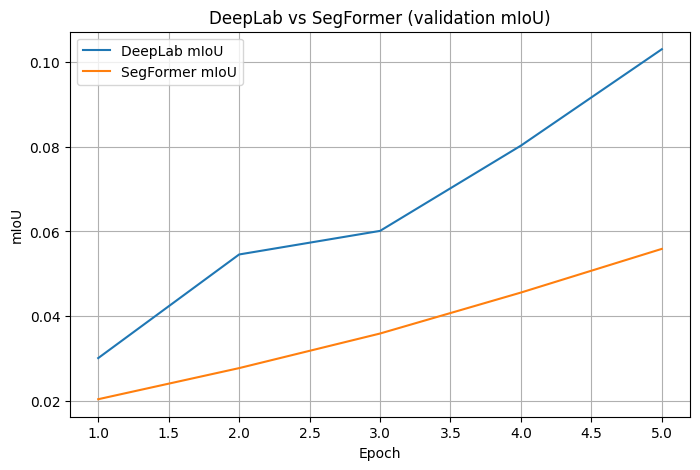

In [ ]:
# Cell 18. Історія навчання та графік mIoU

import pandas as pd

df_dl = pd.DataFrame(history_dl)
df_sf = pd.DataFrame(history_sf)

print("DeepLab training history:")
print(df_dl)

print("\nSegFormer training history:")
print(df_sf)

plt.figure(figsize=(8, 5))
plt.plot(df_dl["epoch"], df_dl["mean_iou"], label="DeepLab mIoU")
plt.plot(df_sf["epoch"], df_sf["mean_iou"], label="SegFormer mIoU")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("DeepLab vs SegFormer (validation mIoU)")
plt.legend()
plt.grid(True)
plt.show()
